# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO

print("Data size: ",df.shape)
print("Column names: ",df.columns)
print("Data types: ",df.dtypes)


Data size:  (891, 15)
Column names:  Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
Data types:  survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object


## A.2. Missing values & Duplicate data

In [12]:
# TODO
print("Missing values: ",df.isnull().sum())
print("Duplicate data: ",df.duplicated().sum())

Missing values:  survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Duplicate data:  107


## A.3. Invalid values

In [13]:
# TODO
df_clean = df[(df['survived'].isin([0,1])) &
              (df['pclass'].isin([1,2,3])) &
              (df['sex'].isin(['male', 'female'])) &
              (df['age'] >= 0) & (df['age'] < 110) &
              (df['sibsp'] >=0) &
              (df['parch'] >=0)&
              (df['fare'] >=0) &
              (df['embarked'].isin(['C','Q','S'])) &
              (df['class'].isin(['First','Second','Third'])) &
              (df['who'].isin(['man','woman','child'])) &
              (df['adult_male'].isin([True,False])) &
              (df['alive'].isin(['yes','no']))&
              (df['alone'].isin([True,False]))
              ]

## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [16]:
# TODO
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1
df_clean.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,1
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False,5
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False,3
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False,2
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False,3


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [17]:
# TODO
df_clean.describe()

,survived,pclass,age,sibsp,parch,fare,family_size
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,0.404494,2.240169,29.642093,0.514045,0.432584,34.567251,1.946629
std,0.491139,0.836854,14.492933,0.930692,0.854181,52.938648,1.485027
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000,1.000000
50%,0.000000,2.000000,28.000000,0.000000,0.000000,15.645850,1.000000
75%,1.000000,3.000000,38.000000,1.000000,1.000000,33.000000,2.000000
max,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200,8.000000


## Group 2 — Dispersion

In [21]:
# TODO
mean = df_clean['fare'].mean()
range = df_clean['fare'].max() - df_clean['fare'].min()
iqr = df_clean['fare'].quantile(0.75) - df_clean['fare'].quantile(0.25)
print("Trung bình: ",mean)
print("Khoảng biến thiên: ",range)
print("Phương sai: ",df['fare'].var())
print("Tứ phân vị: ", iqr)

Trung bình:  34.567251404494385
Khoảng biến thiên:  512.3292
Phương sai:  2469.436845743116
Tứ phân vị:  24.95


## Group 3 — Location and Shape

Mean: 34.57 | Median: 15.65 | Mode: 13.00


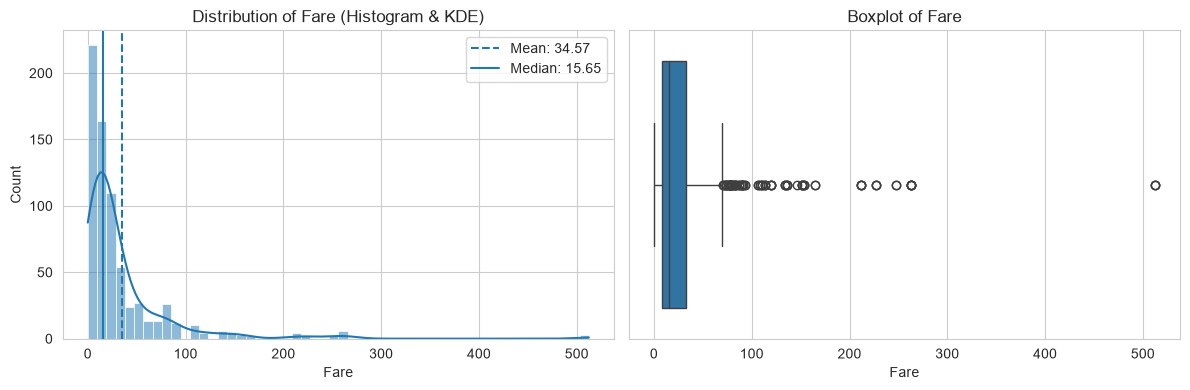

In [22]:
# TODO
# TODO
# Location
mean_val = df_clean['fare'].mean()
median_val = df_clean['fare'].median()
mode_val = df_clean['fare'].mode()[0]

print(f"Mean: {mean_val:.2f} | Median: {median_val:.2f} | Mode: {mode_val:.2f}")

# Shape
plt.figure(figsize=(12, 4))

# 1. Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df_clean['fare'], kde=True)
plt.axvline(mean_val, linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, linestyle='-', label=f'Median: {median_val:.2f}')
plt.title('Distribution of Fare (Histogram & KDE)')
plt.xlabel('Fare')
plt.legend()

# 2. Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['fare'])
plt.title('Boxplot of Fare')
plt.xlabel('Fare')

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [24]:
# TODO
survival_by_class = df_clean.groupby('pclass')['survived'].mean() * 100
print(survival_by_class)

print("Hạng 1 có tỷ lệ sống sót cao nhất, trong khi hạng 3 có tỷ lệ thấp nhất. Chênh lệch giữa hai hạng khá lớn, cho thấy hạng vé có mối liên hệ rõ ràng với khả năng sống sót.")

pclass
1    65.217391
2    47.976879
3    23.943662
Name: survived, dtype: float64
Hạng 1 có tỷ lệ sống sót cao nhất, trong khi hạng 3 có tỷ lệ thấp nhất. Chênh lệch giữa hai hạng khá lớn, cho thấy hạng vé có mối liên hệ rõ ràng với khả năng sống sót.


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [26]:
# TODO
print(df_clean.groupby('sex')['survived'].mean() * 100)
print(df_clean.groupby('pclass')['survived'].mean() * 100)
print(df_clean.groupby(['sex', 'pclass'])['survived'].mean() * 100)

print("Giới tính có ảnh hưởng rất mạnh đến khả năng sống sót, đặc biệt khi so sánh nam và nữ. Tuy nhiên, hạng vé cũng có ảnh hưởng đáng kể, khi hành khách hạng cao có tỷ lệ sống sót tốt hơn.")


sex
female    75.289575
male      20.529801
Name: survived, dtype: float64
pclass
1    65.217391
2    47.976879
3    23.943662
Name: survived, dtype: float64
sex     pclass
female  1         96.385542
        2         91.891892
        3         46.078431
male    1         39.603960
        2         15.151515
        3         15.019763
Name: survived, dtype: float64
Giới tính có ảnh hưởng rất mạnh đến khả năng sống sót, đặc biệt khi so sánh nam và nữ. Tuy nhiên, hạng vé cũng có ảnh hưởng đáng kể, khi hành khách hạng cao có tỷ lệ sống sót tốt hơn.


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [27]:
# TODO
print(df_clean.groupby('survived')['fare'].mean())
print("Nhìn chung, hành khách trả giá vé cao có xu hướng có tỷ lệ sống sót cao hơn. Điều này có thể liên quan đến việc giá vé cao thường đi kèm với hạng vé cao hơn.")

survived
0    22.965456
1    51.647672
Name: fare, dtype: float64
Nhìn chung, hành khách trả giá vé cao có xu hướng có tỷ lệ sống sót cao hơn. Điều này có thể liên quan đến việc giá vé cao thường đi kèm với hạng vé cao hơn.


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [30]:
# TODO
print(df_clean.groupby('family_size')['survived'].mean() * 100)
print("Quy mô gia đình có mối liên hệ với khả năng sống sót. Những người đi cùng gia đình nhỏ có xu hướng sống sót tốt hơn những người đi một mình hoặc thuộc gia đình quá đông.")


family_size
1    31.840796
2    54.676259
3    56.989247
4    77.777778
5    27.272727
6    13.636364
7    33.333333
8     0.000000
Name: survived, dtype: float64
Quy mô gia đình có mối liên hệ với khả năng sống sót. Những người đi cùng gia đình nhỏ có xu hướng sống sót tốt hơn những người đi một mình hoặc thuộc gia đình quá đông.


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [33]:
# TODO
survival_by_town = df_clean.groupby('embark_town')['survived'].mean() * 100
print(survival_by_town)

print("Trong ba cảng lên tàu, cảng có tỷ lệ sống sót cao nhất là Cherbourg. Sự khác biệt này có thể liên quan đến cơ cấu hành khách tại từng cảng, chẳng hạn như hạng vé và giới tính.")

embark_town
Cherbourg      60.769231
Queenstown     28.571429
Southampton    36.281588
Name: survived, dtype: float64
Trong ba cảng lên tàu, cảng có tỷ lệ sống sót cao nhất là Cherbourg. Sự khác biệt này có thể liên quan đến cơ cấu hành khách tại từng cảng, chẳng hạn như hạng vé và giới tính.


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.



*(Viết insight của bạn vào đây...)*

Dữ liệu Titanic cho thấy khả năng sống sót có sự khác biệt rõ rệt giữa các nhóm hành khách. Hành khách hạng 1 có tỷ lệ sống sót cao hơn đáng kể so với hành khách hạng 3, trong khi nữ giới có khả năng sống sót cao hơn nam giới. Những hành khách có giá vé cao cũng có xu hướng sống sót tốt hơn, có thể do giá vé có liên quan đến hạng vé và điều kiện trên tàu. Quy mô gia đình cũng có mối liên hệ với khả năng sống sót, trong đó những gia đình có quy mô vừa phải có xu hướng có kết quả tốt hơn. Ngoài ra, tỷ lệ sống sót khác nhau giữa các cảng lên tàu, cho thấy đặc điểm của từng nhóm hành khách cũng có thể đóng vai trò trong khả năng sống sót.